--- INFO GERAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   event_name  244126 non-null  object        
 1   device_id   244126 non-null  int64         
 2   timestamp   244126 non-null  int64         
 3   exp_id      244126 non-null  int64         
 4   datetime    244126 non-null  datetime64[ns]
 5   date        244126 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 11.2+ MB

Duplicatas totais: 413
Valores nulos: 0

--- ESTATÍSTICAS INICIAIS ---
Total de Eventos: 243713
Total de Usuários: 7551
Média de eventos por usuário: 32.28


<Figure size 1200x600 with 0 Axes>

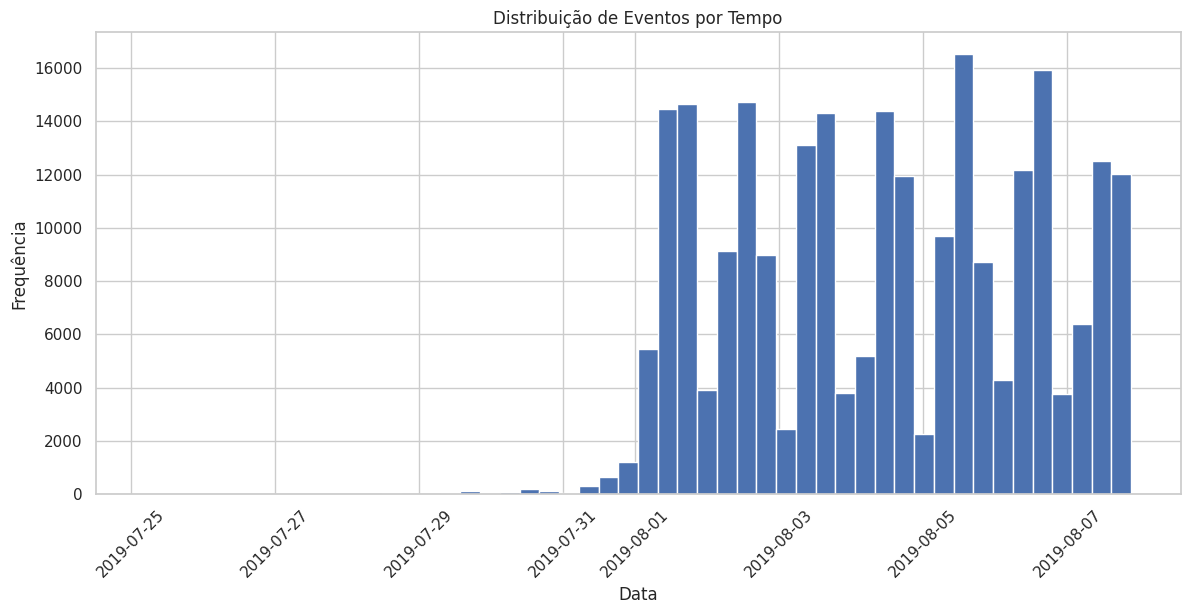

Data Mínima: 2019-07-25 04:43:36
Data Máxima: 2019-08-07 21:15:17


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st
import math
sns.set(style='whitegrid')
plt.figure(figsize=(12, 6))
try:
    df = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')
except:
    df = pd.read_csv('/datasets/logs_exp_us.csv')
df.columns = ['event_name', 'device_id', 'timestamp', 'exp_id']
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
df['date'] = df['datetime'].dt.date
print("--- INFO GERAL ---")
df.info()
print(f"\nDuplicatas totais: {df.duplicated().sum()}")
print(f"Valores nulos: {df.isnull().sum().sum()}")
df = df.drop_duplicates().reset_index(drop=True)
print("\n--- ESTATÍSTICAS INICIAIS ---")
n_events = len(df)
n_users = df['device_id'].nunique()
print(f"Total de Eventos: {n_events}")
print(f"Total de Usuários: {n_users}")
print(f"Média de eventos por usuário: {n_events / n_users:.2f}")
plt.figure(figsize=(14, 6))
df['datetime'].hist(bins=50)
plt.title('Distribuição de Eventos por Tempo')
plt.xlabel('Data')
plt.ylabel('Frequência')
plt.xticks(rotation=45)
plt.show()
print(f"Data Mínima: {df['datetime'].min()}")
print(f"Data Máxima: {df['datetime'].max()}")

In [2]:
date_cutoff = pd.to_datetime('2019-08-01').date()
df_filtered = df[df['date'] >= date_cutoff]
loss_events = 1 - (len(df_filtered) / len(df))
loss_users = 1 - (df_filtered['device_id'].nunique() / df['device_id'].nunique())
print(f"Perda de Eventos: {loss_events:.1%}")
print(f"Perda de Usuários: {loss_users:.1%}")
print(f"Grupos presentes nos dados filtrados: {df_filtered['exp_id'].unique()}")
events_freq = df_filtered['event_name'].value_counts()
print("\n--- EVENTOS MAIS COMUNS ---")
print(events_freq)
users_per_event = df_filtered.groupby('event_name')['device_id'].nunique().sort_values(ascending=False)
print("\n--- USUÁRIOS POR EVENTO ---")
print(users_per_event)
funnel_order = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']
funnel_data = users_per_event[funnel_order]
print("\n--- TAXA DE CONVERSÃO DO FUNIL ---")
print(f"Etapa 1: {funnel_order[0]} -> {funnel_data[0]} usuários (100%)")
for i in range(1, len(funnel_order)):
    step_name = funnel_order[i]
    users_current = funnel_data[i]
    users_prev = funnel_data[i-1]
    conversion = users_current / users_prev
    total_conversion = users_current / funnel_data[0]
    print(f"Etapa {i+1}: {step_name} -> {users_current} usuários")
    print(f"   Conversão da etapa anterior: {conversion:.1%}")
    print(f"   Conversão total (desde o início): {total_conversion:.1%}")
drop_step1 = 1 - (funnel_data[1] / funnel_data[0])
print(f"\nPerda na primeira etapa (Main -> Offers): {drop_step1:.1%}")

Perda de Eventos: 1.2%
Perda de Usuários: 0.2%
Grupos presentes nos dados filtrados: [246 247 248]

--- EVENTOS MAIS COMUNS ---
MainScreenAppear           117328
OffersScreenAppear          46333
CartScreenAppear            42303
PaymentScreenSuccessful     33918
Tutorial                     1005
Name: event_name, dtype: int64

--- USUÁRIOS POR EVENTO ---
event_name
MainScreenAppear           7419
OffersScreenAppear         4593
CartScreenAppear           3734
PaymentScreenSuccessful    3539
Tutorial                    840
Name: device_id, dtype: int64

--- TAXA DE CONVERSÃO DO FUNIL ---
Etapa 1: MainScreenAppear -> 7419 usuários (100%)
Etapa 2: OffersScreenAppear -> 4593 usuários
   Conversão da etapa anterior: 61.9%
   Conversão total (desde o início): 61.9%
Etapa 3: CartScreenAppear -> 3734 usuários
   Conversão da etapa anterior: 81.3%
   Conversão total (desde o início): 50.3%
Etapa 4: PaymentScreenSuccessful -> 3539 usuários
   Conversão da etapa anterior: 94.8%
   Conversão tota

In [3]:
users_by_group = df_filtered.groupby('exp_id')['device_id'].nunique()
events_by_group = df_filtered.pivot_table(
    index='event_name',
    columns='exp_id',
    values='device_id',
    aggfunc='nunique'
).reset_index()
events_by_group = events_by_group.sort_values(by=246, ascending=False)
print("--- TABELA DE USUÁRIOS POR EVENTO E GRUPO ---")
print(users_by_group)
print("\n")
display(events_by_group)
def z_test(group1, group2, alpha=0.05):
    print(f"\n=== TESTE Z: Grupo {group1} vs Grupo {group2} (Alpha: {alpha}) ===")
    for i in events_by_group.index:
        event = events_by_group.loc[i, 'event_name']
        if event == 'Tutorial': continue
        successes1 = events_by_group.loc[i, group1]
        successes2 = events_by_group.loc[i, group2]
        trials1 = users_by_group[group1]
        trials2 = users_by_group[group2]
        p1 = successes1 / trials1
        p2 = successes2 / trials2
        p_combined = (successes1 + successes2) / (trials1 + trials2)
        difference = p1 - p2
        z_value = difference / np.sqrt(p_combined * (1 - p_combined) * (1/trials1 + 1/trials2))
        distr = st.norm(0, 1)
        p_value = (1 - distr.cdf(abs(z_value))) * 2
        print(f"Evento: {event:25} | p-value: {p_value:.5f} -> ", end="")
        if p_value < alpha:
            print("Diferença Significativa! (Rejeita H0) ⚠️")
        else:
            print("Sem diferença (Não rejeita H0) ✅")
z_test(246, 247, alpha=0.05)
z_test(246, 248, alpha=0.05)
z_test(247, 248, alpha=0.05)
users_by_group['combined'] = users_by_group[246] + users_by_group[247]
events_by_group['combined'] = events_by_group[246] + events_by_group[247]
z_test('combined', 248, alpha=0.05)

--- TABELA DE USUÁRIOS POR EVENTO E GRUPO ---
exp_id
246    2484
247    2513
248    2537
Name: device_id, dtype: int64




exp_id,event_name,246,247,248
1,MainScreenAppear,2450,2476,2493
2,OffersScreenAppear,1542,1520,1531
0,CartScreenAppear,1266,1238,1230
3,PaymentScreenSuccessful,1200,1158,1181
4,Tutorial,278,283,279



=== TESTE Z: Grupo 246 vs Grupo 247 (Alpha: 0.05) ===
Evento: MainScreenAppear          | p-value: 0.75706 -> Sem diferença (Não rejeita H0) ✅
Evento: OffersScreenAppear        | p-value: 0.24810 -> Sem diferença (Não rejeita H0) ✅
Evento: CartScreenAppear          | p-value: 0.22883 -> Sem diferença (Não rejeita H0) ✅
Evento: PaymentScreenSuccessful   | p-value: 0.11457 -> Sem diferença (Não rejeita H0) ✅

=== TESTE Z: Grupo 246 vs Grupo 248 (Alpha: 0.05) ===
Evento: MainScreenAppear          | p-value: 0.29497 -> Sem diferença (Não rejeita H0) ✅
Evento: OffersScreenAppear        | p-value: 0.20836 -> Sem diferença (Não rejeita H0) ✅
Evento: CartScreenAppear          | p-value: 0.07843 -> Sem diferença (Não rejeita H0) ✅
Evento: PaymentScreenSuccessful   | p-value: 0.21226 -> Sem diferença (Não rejeita H0) ✅

=== TESTE Z: Grupo 247 vs Grupo 248 (Alpha: 0.05) ===
Evento: MainScreenAppear          | p-value: 0.45871 -> Sem diferença (Não rejeita H0) ✅
Evento: OffersScreenAppear        

## Conclusão Final do Teste A/B

1.  **Qualidade do Teste (A/A):**
    A comparação entre os grupos de controle (246 e 247) não mostrou diferenças estatisticamente significativas (p-values > 0.05). Isso valida a divisão dos grupos e garante a confiabilidade do experimento.

2.  **Impacto da Alteração de Fonte (A/B):**
    Comparando o grupo de teste (248) com os grupos de controle (tanto isoladamente quanto combinados), não encontramos nenhuma diferença estatisticamente significativa em nenhuma das etapas do funil (Main Screen, Offers, Cart, Payment).

3.  **Veredito:**
    A alteração das fontes **não afetou o comportamento dos usuários**. As taxas de conversão permaneceram estáveis.
    **Recomendação:** A equipe de design pode implementar as novas fontes se desejar, pois não há evidências de que isso prejudicará as vendas ou a experiência do usuário. O receio dos gerentes de que o design seria "intimidador" não se confirmou nos dados.